In [2]:
import pandas as pd 
import numpy as np 

#ML
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import random
from sklearn.metrics import r2_score
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import seaborn as sns
from tqdm import tqdm

In [3]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import norm
import matplotlib.pyplot as plt

# Function to calculate confidence interval for accuracy
def compute_confidence_interval(accuracy, n, confidence=0.95):
    z = norm.ppf((1 + confidence) / 2)  # z-score for the given confidence level
    ci = z * np.sqrt((accuracy * (1 - accuracy)) / n)
    return accuracy - ci, accuracy + ci


In [14]:
from sklearn.metrics import mean_absolute_percentage_error

network_names = ["school","email_eu_modified","conf"]

# Fixed network name
r2_score_family = [] 
ci_lower_family = [] 
ci_upper_family = [] 

for network_name in network_names:
    
    r2_score_list = [] 
    ci_lower_list  = [] 
    ci_upper_list  = [] 
    
    obs_ratio_list = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]

    for partial_observation in tqdm(obs_ratio_list):
        fixed_network_name = network_name 
        directory = "../result_85stop_10%init_nodes_limited-v4/unweighted/"
        
        df_merge = pd.DataFrame()
        
        for filename in os.listdir(directory):
            if filename.endswith('EPH-v3.csv') and f"unweighted_complex_{fixed_network_name}_theta_" in filename:
                match = re.search(r"theta_([0-9]+)_prob_0.02limited-node_([0-9.]+)_EPH-v3\.csv", filename)
                if match:
                    if float(match.group(2)) == partial_observation:
                        beta = int(match.group(1))
                        file_path = os.path.join(directory, filename)
                        df_new = pd.read_csv(file_path)
                        df_new["theta"] = beta
                        df_merge = pd.concat([df_merge,df_new])
    
        df_merge["EPH"]  = df_merge["EPH"].fillna(0)
        df_merge = df_merge.sample(frac=1,random_state=42)
        X = df_merge[['EPH']]
        y = df_merge['theta']

        X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=143, test_size=0.2)
        
        poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
        poly_model.fit(X_train, y_train)
        y_poly_pred = poly_model.predict(X_test)
        
        # --- MAPE Calculation (Point Estimate) ---
        mape_point_estimate = mean_absolute_percentage_error(y_test, y_poly_pred)

        # --- Bootstrapping for Confidence Interval ---
        n_iterations = 1000
        confidence_level = 0.95
        bootstrap_mape_scores = []
        
        y_test_np = y_test.to_numpy() 
        rng = np.random.RandomState(100)
        
        for i in range(n_iterations):
            indices = rng.choice(range(len(y_test_np)), size=len(y_test_np), replace=True)
            X_test_bs = X_test.iloc[indices] 
            y_test_bs = y_test_np[indices]
            
            if len(np.unique(y_test_bs)) < 2:
                continue
        
            y_pred_bs = poly_model.predict(X_test_bs)
            mape_bs = mean_absolute_percentage_error(y_test_bs, y_pred_bs)
            bootstrap_mape_scores.append(mape_bs)
        
        alpha = (1 - confidence_level) / 2.0
        lower_bound = np.percentile(bootstrap_mape_scores, alpha * 100)
        upper_bound = np.percentile(bootstrap_mape_scores, (1 - alpha) * 100)

        r2_score_list.append(mape_point_estimate)
        ci_lower_list.append(lower_bound)
        ci_upper_list.append(upper_bound)

    r2_score_family.append(r2_score_list)
    ci_upper_family.append(ci_upper_list)
    ci_lower_family.append(ci_lower_list)


100%|█████████████████████████████████████████████| 9/9 [00:03<00:00,  2.99it/s]


In [16]:
# network_names = ["school","email_eu_modified","conf"]
# network_names = ["school","email_eu_modified","conf"]
# # network_names = ["email_eu_modified"]


# # Fixed network name

# r2_score_family = [] 
# ci_lower_family = [] 
# ci_upper_family = [] 

# for network_name in network_names:
    
#     r2_score_list = [] 
#     ci_lower_list  = [] 
#     ci_upper_list  = [] 
    
#     obs_ratio_list = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]


        
#     for partial_observation in tqdm(obs_ratio_list):
#         fixed_network_name = network_name 
#         # Loop through all files in the directory
#         directory = "../result_85stop_10%init_nodes_limited-v4/unweighted/"
        
#         df_merge = pd.DataFrame()
        
#         # Loop through all files in the directory
#         for filename in os.listdir(directory):
#             # Check if the filename matches the pattern and contains the fixed network_name
#             if filename.endswith('EPH-v3.csv') and f"unweighted_complex_{fixed_network_name}_theta_" in filename:
#                 # Use regex to extract the beta value from the filename
#                 match = re.search(r"theta_([0-9]+)_prob_0.02limited-node_([0-9.]+)_EPH-v3\.csv", filename)
#                 # match = re.search(r"beta_([0-9.]+)limited-node_0.1_EPH-v3\.csv", filename)
#                 # print("match1")
#                 if match:
#                     # print("match")
#                     # print(fixed_network_name)
#                     # print(float(match.group(2)))
#                     if float(match.group(2)) == partial_observation:
#                         beta = int(match.group(1))  # Convert beta to a float
#                         file_path = os.path.join(directory, filename)
#                         df_new = pd.read_csv(file_path)
#                         df_new["theta"] = beta
#                         df_merge = pd.concat([df_merge,df_new])
    
   
                
#         # df_merge = df_merge[~df_merge["EPH"].isna()]
#         df_merge["EPH"]  = df_merge["EPH"].fillna(0)
#         # df_merge = df_merge[df_merge["theta"] > 0.021]
#         df_merge = df_merge.sample(frac=1,random_state=42)
#         X = df_merge[['EPH']]
#         y = df_merge['theta']

        
    
#         # Assuming X and y are already defined as Pandas DataFrames or Series
#         # Splitting the dataset
#         X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=143, test_size=0.2)
        
#         # Polynomial Regression (Degree 2)
#         poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
#         poly_model.fit(X_train, y_train)
#         y_poly_pred = poly_model.predict(X_test)
        
#         # Calculating R^2 score for polynomial regression
#         r2_poly = r2_score(y_test, y_poly_pred)
#         # --- R-squared Calculation (Point Estimate) ---
#         y_poly_pred_test = poly_model.predict(X_test)
#         r2_poly_point_estimate = r2_score(y_test, y_poly_pred_test)

#         # --- Bootstrapping for Confidence Interval ---
#         n_iterations = 1000  # Number of bootstrap samples
#         confidence_level = 0.95
#         bootstrap_r2_scores = []
        
#         # Ensure y_test is a numpy array for easier indexing if needed
#         y_test_np = y_test.to_numpy() 
#         # Ensure X_test is ready for prediction (it should be a DataFrame here)
        
#         rng = np.random.RandomState(42) # Seed the random number generator for reproducibility
        
#         for i in range(n_iterations):
#             # Sample indices with replacement from the test set
#             indices = rng.choice(range(len(y_test_np)), size=len(y_test_np), replace=True)
            
#             # Create bootstrap samples using the sampled indices
#             # Ensure X_test_bs maintains the DataFrame structure expected by the pipeline
#             X_test_bs = X_test.iloc[indices] 
#             y_test_bs = y_test_np[indices]
            
#             # Handle cases where bootstrap sample might be trivial (e.g., all y values are the same)
#             if len(np.unique(y_test_bs)) < 2:
#                 continue # Skip this iteration as R2 is ill-defined or 0/1
        
#             # Predict using the *original* trained model
#             y_pred_bs = poly_model.predict(X_test_bs)
            
#             # Calculate R^2 for the bootstrap sample
#             r2_bs = r2_score(y_test_bs, y_pred_bs)
#             # if r2_bs < 0:
#             #     continue # R2 is ill-defined 
#             bootstrap_r2_scores.append(r2_bs)
        
#         # Calculate the confidence interval using percentiles
#         alpha = (1 - confidence_level) / 2.0
#         lower_bound = np.percentile(bootstrap_r2_scores, alpha * 100)
#         upper_bound = np.percentile(bootstrap_r2_scores, (1 - alpha) * 100)


        
        

        
        
        
#         r2_score_list.append(r2_poly_point_estimate)
#         ci_lower_list.append(lower_bound)
#         ci_upper_list.append(upper_bound)

#     r2_score_family.append(r2_score_list)
#     ci_upper_family.append(ci_upper_list)
#     ci_lower_family.append(ci_lower_list)

    

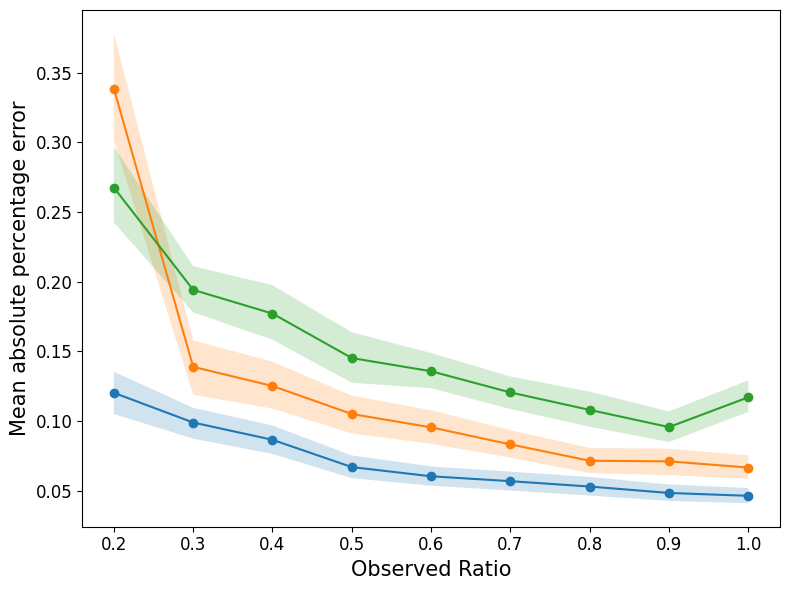

In [18]:
##-----------------------------------------------------------------
# Create the plot
plt.figure(figsize=(8, 6))

["school","email_eu_modified","conf"]
#email
plt.plot(obs_ratio_list, r2_score_family[1], marker='o',label="email")
plt.fill_between(obs_ratio_list, ci_lower_family[1], ci_upper_family[1], alpha=0.2)

plt.plot(obs_ratio_list, r2_score_family[2], marker='o',label="conference")
plt.fill_between(obs_ratio_list, ci_lower_family[2], ci_upper_family[2], alpha=0.2)

plt.plot(obs_ratio_list, r2_score_family[0], marker='o',label="school")
plt.fill_between(obs_ratio_list, ci_lower_family[0], ci_upper_family[0], alpha=0.2)




# Set x-axis to show only integer values
plt.xticks(obs_ratio_list)


plt.xlabel('Observed Ratio',fontsize=15)
plt.ylabel('Mean absolute percentage error',fontsize=15)
# plt.legend(loc='lower right',fontsize=15)

# plt.ylim(0.90,1.01)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.legend(loc='lower right',fontsize=15)


# plt.grid(True) 
# plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f'../plot-april-final-version/fig4-panelB-mape.pdf', format='pdf', dpi=1200, bbox_inches='tight')
# plt.show()